# Klasifikasi Kategori: Fine-tuning IndoBERT

## Latar Belakang

Komponen klasifikasi merupakan salah satu pilar sistem RAG yang dibangun. Model klasifikasi kategori berperan ganda: pada tahap penyiapan data ia dapat menandai kategori artikel sebagai metadata, sedangkan pada saat sistem berjalan (run-time) ia mengklasifikasikan pertanyaan pengguna untuk mengarahkan proses pencarian (routing) ke kategori yang relevan. Dengan demikian, kualitas model klasifikasi berdampak langsung pada ketepatan retrieval pada sistem akhir.

## Tujuan

Tahap ini bertujuan melatih model IndoBERT untuk mengklasifikasikan artikel berita ke dalam lima kategori (news, finance, sport, inet, dan health) melalui pencarian hyperparameter, lalu memilih dan menyimpan konfigurasi terbaik untuk digunakan kembali dalam sistem.

## Alur Proses

1. Memuat data hasil pembagian (`data/splits/{train,val,test}.csv`) dan membangun pemetaan label untuk lima kelas.
2. Melakukan tokenisasi menggunakan isi artikel sebagai masukan model.
3. Menjalankan pencarian hyperparameter dengan tiga learning rate (2e-5, 3e-5, dan 5e-5) serta seed tetap (42), lalu memilih model dengan F1-macro validasi tertinggi.
4. Mengevaluasi model terbaik pada test set menggunakan akurasi, F1, dan confusion matrix 5x5.
5. Menyimpan model terbaik ke `models/indobert_classifier/`.
6. Mendemonstrasikan klasifikasi terhadap contoh pertanyaan pengguna sebagai pratinjau mekanisme routing pada saat sistem berjalan.

## Catatan Teknis

Tahap ini memerlukan akselerasi GPU dan mensyaratkan berkas pada `data/splits/` (hasil tahap pemrosesan) telah tersedia, dengan label kategori sesuai sumbernya (`inet`). Karena jumlah artikel relatif sedikit, proses pelatihan ketiga konfigurasi berlangsung cepat.

In [1]:
!pip install -q transformers torch datasets scikit-learn pandas matplotlib accelerate

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root():
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists() and (cwd / "notebooks").exists():
        return cwd
    for parent in cwd.parents:
        if (parent / "data").exists() and (parent / "notebooks").exists():
            return parent
    return cwd

PROJECT_ROOT = find_project_root()
DATA_SPLITS = PROJECT_ROOT / "data" / "splits"
MODELS_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
for d in [MODELS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\user\news-rag-project


Tahap ini menyiapkan kebutuhan dasar sebelum pelatihan dijalankan. Pustaka yang dimuat mencakup `pandas` dan `numpy` untuk pengolahan data serta `matplotlib` untuk visualisasi. Lokasi root proyek dideteksi secara otomatis agar jalur berkas tetap konsisten, dengan folder data hasil pembagian (`data/splits`) sebagai sumber masukan, serta folder penyimpanan model (`models`) dan visualisasi (`reports/figures`) disiapkan sebagai keluaran.

## Load Splits + Mapping Label

In [3]:
train_df = pd.read_csv(DATA_SPLITS / "train.csv")
val_df   = pd.read_csv(DATA_SPLITS / "val.csv")
test_df  = pd.read_csv(DATA_SPLITS / "test.csv")

# Mapping kategori -> id (urut alfabet, deterministik)
categories = sorted(train_df["kategori"].unique())
LABEL2ID = {c: i for i, c in enumerate(categories)}
ID2LABEL = {i: c for c, i in LABEL2ID.items()}
print(f"Kategori ({len(categories)}): {LABEL2ID}")

for df in [train_df, val_df, test_df]:
    df["label"] = df["kategori"].map(LABEL2ID)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nDistribusi kategori (train):")
print(train_df["kategori"].value_counts())

Kategori (5): {'finance': 0, 'health': 1, 'inet': 2, 'news': 3, 'sport': 4}

Train: 1472 | Val: 184 | Test: 184

Distribusi kategori (train):
kategori
news       318
finance    300
sport      293
inet       287
health     274
Name: count, dtype: int64


Ketiga subset data dimuat dari folder `data/splits/`, menghasilkan 1.472 artikel latih, 184 validasi, dan 184 uji. Pemetaan label dibangun dari lima kategori unik yang diurutkan secara alfabet (finance, health, inet, news, sport) agar penomoran kelas bersifat deterministik dan konsisten. Setiap kategori kemudian dipetakan ke id numerik yang menjadi target pelatihan. Distribusi kategori pada data latih tetap relatif seimbang, sesuai hasil pembagian stratified pada tahap sebelumnya.

## Tokenize

In [4]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["isi"], truncation=True, max_length=256)

def to_ds(df):
    ds = Dataset.from_pandas(df[["isi", "label"]]).map(tokenize_fn, batched=True)
    return ds.remove_columns(["isi"]).rename_column("label", "labels")

train_ds, val_ds, test_ds = to_ds(train_df), to_ds(val_df), to_ds(test_df)
print("Tokenisasi selesai.")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

Map:   0%|          | 0/1472 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Tokenisasi selesai.
Device: GPU


Isi artikel ditokenisasi menggunakan tokenizer IndoBERT (`indobenchmark/indobert-base-p1`) yang menjadi model dasar. Panjang maksimum ditetapkan 256 token, lebih panjang dibandingkan tahap sentimen, agar model memperoleh konteks yang lebih kaya dari isi artikel untuk menentukan kategori secara akurat. Data kemudian dikonversi ke format Dataset Hugging Face agar siap digunakan dalam pelatihan, dengan proses dijalankan pada GPU.

## Hyperparameter Tuning (3 Learning Rate)

Sebagaimana pada pelatihan model sentimen, dilakukan pencarian hyperparameter pada tiga nilai learning rate yang umum direkomendasikan untuk fine-tuning BERT, yaitu 2e-5, 3e-5, dan 5e-5, dengan jumlah epoch (3) dan ukuran batch (16) dibuat tetap. Seed (42) ditetapkan ulang sebelum setiap konfigurasi dilatih agar inisialisasi lapisan klasifikasi dan pengacakan data identik di semua percobaan, sehingga perbandingan bersifat adil dan dapat direproduksi. Setiap konfigurasi dievaluasi pada data validasi, dan model dengan F1-macro tertinggi dipilih secara otomatis melalui mekanisme `load_best_model_at_end`.


In [7]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding, set_seed)
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
NUM_LABELS = len(categories)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro")}

SEARCH_SPACE = [2e-5, 3e-5, 5e-5]
EPOCHS = 3

results = []
best = {"f1": -1.0, "lr": None, "trainer": None}

for lr in SEARCH_SPACE:
    print(f"\n{'='*45}\n  TRAINING lr={lr}\n{'='*45}")
    set_seed(SEED)   # init head & shuffling identik tiap config
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID)
    args = TrainingArguments(
        output_dir=str(MODELS_DIR / f"clf_ckpt_lr{lr}"),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        seed=SEED,
        data_seed=SEED,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=1,
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                      eval_dataset=val_ds, tokenizer=tokenizer,
                      data_collator=data_collator, compute_metrics=compute_metrics)
    trainer.train()
    val = trainer.evaluate(val_ds)
    print(f">> lr={lr}: val_acc={val['eval_accuracy']:.4f}, val_f1={val['eval_f1_macro']:.4f}")
    results.append({"lr": lr, "val_accuracy": round(val["eval_accuracy"], 4),
                    "val_f1_macro": round(val["eval_f1_macro"], 4)})
    if val["eval_f1_macro"] > best["f1"]:
        if best["trainer"] is not None:
            del best["trainer"]; torch.cuda.empty_cache()
        best = {"f1": val["eval_f1_macro"], "lr": lr, "trainer": trainer}
    else:
        del trainer, model; torch.cuda.empty_cache()

print("\n=== Hasil Hyperparameter Search ===")
print(pd.DataFrame(results).to_string(index=False))
print(f"\nBEST: lr={best['lr']} (val f1_macro={best['f1']:.4f})")

trainer = best["trainer"]


  TRAINING lr=2e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user\AppData\Local\Temp\ipykernel_78528\1904971623.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, train_dataset=train_ds,


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.752500,0.224776,0.934783,0.933113
2,0.242700,0.169493,0.934783,0.935172
3,0.125800,0.200870,0.940217,0.940749


>> lr=2e-05: val_acc=0.9402, val_f1=0.9407

  TRAINING lr=3e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user\AppData\Local\Temp\ipykernel_78528\1904971623.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, train_dataset=train_ds,


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.677200,0.208906,0.934783,0.934861
2,0.220200,0.206482,0.929348,0.929739
3,0.098300,0.246497,0.918478,0.918854


>> lr=3e-05: val_acc=0.9348, val_f1=0.9349

  TRAINING lr=5e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user\AppData\Local\Temp\ipykernel_78528\1904971623.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, train_dataset=train_ds,


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.678100,0.242453,0.907609,0.906637
2,0.231100,0.227849,0.934783,0.935201
3,0.096800,0.297630,0.923913,0.924411


>> lr=5e-05: val_acc=0.9348, val_f1=0.9352

=== Hasil Hyperparameter Search ===
     lr  val_accuracy  val_f1_macro
0.00002        0.9402        0.9407
0.00003        0.9348        0.9349
0.00005        0.9348        0.9352

BEST: lr=2e-05 (val f1_macro=0.9407)


Hasil pencarian menunjukkan ketiga konfigurasi mencapai performa yang berdekatan dan tinggi, dengan F1-macro validasi pada kisaran 0,935 hingga 0,941. Konfigurasi dengan learning rate 2e-5 memberikan hasil terbaik, yaitu akurasi validasi 0,9402 dan F1-macro 0,9407, sehingga dipilih untuk dievaluasi pada test set dan disimpan sebagai model final.

## Evaluasi Best Model di Test Set

=== Test Set (best lr=2e-05) ===
Accuracy : 0.9565
F1 macro : 0.9560

              precision    recall  f1-score   support

     finance       0.97      0.95      0.96        38
      health       0.97      0.94      0.96        34
        inet       0.94      0.92      0.93        36
        news       0.97      0.97      0.97        40
       sport       0.92      1.00      0.96        36

    accuracy                           0.96       184
   macro avg       0.96      0.96      0.96       184
weighted avg       0.96      0.96      0.96       184



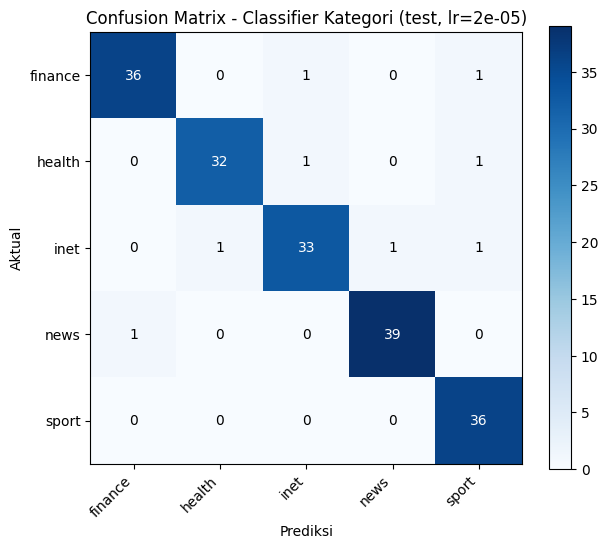


Saved -> C:\Users\user\news-rag-project\reports\figures\classifier_confusion_matrix.png


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

pred_out = trainer.predict(test_ds)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

print(f"=== Test Set (best lr={best['lr']}) ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"F1 macro : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=categories)}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_LABELS)); ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_yticks(range(NUM_LABELS)); ax.set_yticklabels(categories)
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
ax.set_title(f"Confusion Matrix - Classifier Kategori (test, lr={best['lr']})")
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout()
plt.savefig(FIG_DIR / "classifier_confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"\nSaved -> {FIG_DIR / 'classifier_confusion_matrix.png'}")

Model terbaik (learning rate 2e-5) dievaluasi pada test set dan menghasilkan performa yang sangat baik, yaitu akurasi 0,9565 dan F1-macro 0,9560. Performa konsisten tinggi di seluruh kelas, dengan F1 berkisar antara 0,93 hingga 0,97. Kategori news mencapai F1 tertinggi (0,97), sedangkan inet menjadi yang sedikit lebih rendah (0,93), yang wajar mengingat berita teknologi kerap bersinggungan dengan topik lain seperti bisnis maupun sains.

Confusion matrix memperlihatkan pola yang hampir sepenuhnya diagonal, menandakan kesalahan klasifikasi sangat sedikit dan tersebar tanpa kebingungan sistematis antar kategori tertentu. Akurasi yang tinggi ini penting karena model klasifikasi berperan langsung dalam mengarahkan proses pencarian (routing) pada sistem RAG, sehingga ketepatan kategori berdampak pada relevansi artikel yang diambil.

## Simpan Best Model

In [9]:
save_path = MODELS_DIR / "indobert_classifier"
trainer.save_model(str(save_path))
tokenizer.save_pretrained(str(save_path))
print(f"Best classifier (lr={best['lr']}) disimpan -> {save_path}")

Best classifier (lr=2e-05) disimpan -> C:\Users\user\news-rag-project\models\indobert_classifier


Model klasifikasi terbaik beserta tokenizer-nya disimpan ke `models/indobert_classifier/`, sehingga dapat dimuat kembali untuk menandai kategori artikel maupun mengklasifikasikan pertanyaan pengguna pada sistem RAG tanpa perlu melatih ulang.

## Demonstrasi Routing Query

In [10]:
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
clf = pipeline("text-classification", model=str(save_path),
               tokenizer=str(save_path), device=device, truncation=True, max_length=256)

contoh_query = [
    "Bagaimana kabar ekonomi dan pergerakan saham terbaru?",
    "Hasil pertandingan dan klasemen sepak bola pekan ini",
    "Tips menjaga kesehatan jantung dan pola makan sehat",
    "Spesifikasi dan harga smartphone flagship terbaru",
    "Bagaimana antusiasme umat muslim Idul Adha?",
]
print("Demo routing query -> kategori:\n")
for q in contoh_query:
    r = clf(q)[0]
    print(f"  [{r['label']:<9} {r['score']:.2f}] {q}")

Device set to use cuda:0


Demo routing query -> kategori:

  [finance   0.94] Bagaimana kabar ekonomi dan pergerakan saham terbaru?
  [sport     0.81] Hasil pertandingan dan klasemen sepak bola pekan ini
  [health    0.89] Tips menjaga kesehatan jantung dan pola makan sehat
  [inet      0.94] Spesifikasi dan harga smartphone flagship terbaru
  [news      0.65] Bagaimana antusiasme umat muslim Idul Adha?


Sebagai pratinjau mekanisme pada saat sistem berjalan, model diterapkan untuk mengklasifikasikan lima contoh pertanyaan pengguna ke dalam kategori. Seluruh pertanyaan berhasil diarahkan ke kategori yang tepat, dengan tingkat keyakinan yang bervariasi mengikuti seberapa spesifik pertanyaan tersebut terhadap suatu topik. Pertanyaan yang mengarah jelas pada satu bidang memperoleh keyakinan tinggi, yaitu ekonomi dan saham ke finance (0,94), sepak bola ke sport (0,81), kesehatan jantung ke health (0,89), dan smartphone ke inet (0,94).

Sementara itu, pertanyaan yang bersifat lebih umum, seperti antusiasme umat muslim menyambut Idul Adha, diarahkan ke news dengan keyakinan yang lebih moderat (0,65). Hal ini wajar karena topik berita umum memiliki batas yang lebih luas dan tidak setajam topik khusus seperti finance atau teknologi. Variasi nilai keyakinan ini bermanfaat bagi sistem RAG: skor keyakinan dapat dijadikan sinyal routing, di mana keyakinan tinggi mendorong penyaringan kategori yang tegas, sedangkan keyakinan yang lebih rendah membuat sistem lebih berhati-hati dalam menerapkan filter agar pencarian tetap relevan.

Tahap klasifikasi kategori telah menghasilkan model IndoBERT terlatih dengan performa tinggi (akurasi test 0,9565 dan F1-macro 0,9560), tersimpan pada `models/indobert_classifier/`. Model ini siap menjalankan dua peran dalam sistem, yaitu menandai kategori artikel sebagai metadata dan mengarahkan pertanyaan pengguna (routing) pada saat sistem berjalan. Dengan komponen klasifikasi dan sentimen telah tersedia, tahap berikutnya membangun basis pengetahuan sistem, yaitu memecah artikel menjadi potongan (chunk), mengubahnya menjadi representasi vektor (embedding), dan menyimpannya ke dalam vector database untuk pencarian semantik.